#  1. Install Libraries

In [2]:
!pip install pandas numpy plotly matplotlib seaborn requests beautifulsoup4 lxml -q

print("✅ All libraries installed")

✅ All libraries installed


# 2. Imports

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Imports done")

✅ Imports done


# 3.  Upload and Load CSVs

In [4]:
import os
import pandas as pd

# ⚠️ Updated to point to your exact GitHub repo and the 'data/raw/' folder
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/ENIYAND/tn-election-2026-analysis/main/data/raw/"

def get_data(filename):
    # 1. Try to load from the local folder first
    if os.path.exists(f"./{filename}"):
        print(f"✅ Loaded {filename} locally.")
        return pd.read_csv(f"./{filename}")

    # 2. Try to load from your personal Google Drive (for your own development)
    drive_path = f"/content/drive/MyDrive/TN_elections_project/{filename}"
    if os.path.exists(drive_path):
        print(f"✅ Loaded {filename} from Google Drive.")
        return pd.read_csv(drive_path)

    # 3. If neither exist, download it directly from your GitHub repo!
    print(f"🌐 Fetching {filename} from GitHub...")
    return pd.read_csv(GITHUB_RAW_BASE + filename)

# ─── Load Data ──────────────────────────────────────────
master       = get_data('constituency_master.csv')
results_2021 = get_data('tn_2021_results.csv')
results_2026 = get_data('tn_2026_results.csv')

print("=" * 55)
print("CONSTITUENCY MASTER")
print(f"  Shape      : {master.shape}")
print(f"  Columns    : {list(master.columns)}")
print()

print("2021 RESULTS")
print(f"  Shape      : {results_2021.shape}")
print(f"  Columns    : {list(results_2021.columns)}")
print()

print("2026 RESULTS")
print(f"  Shape      : {results_2026.shape}")
print(f"  Columns    : {list(results_2026.columns)}")
print("=" * 55)

print("\n--- First 3 rows of each ---")
print("\nMaster:"); display(master.head(3))
print("\n2021:"); display(results_2021.head(3))
print("\n2026:"); display(results_2026.head(3))

🌐 Fetching constituency_master.csv from GitHub...
🌐 Fetching tn_2021_results.csv from GitHub...
🌐 Fetching tn_2026_results.csv from GitHub...
CONSTITUENCY MASTER
  Shape      : (234, 5)
  Columns    : ['ac_number', 'constituency', 'district', 'region', 'reserved']

2021 RESULTS
  Shape      : (4232, 8)
  Columns    : ['constituency', 'ac_number', 'candidate', 'party', 'votes', 'turnout', 'reserved', 'region']

2026 RESULTS
  Shape      : (4257, 8)
  Columns    : ['constituency', 'ac_number', 'candidate', 'party', 'votes', 'turnout', 'reserved', 'region']

--- First 3 rows of each ---

Master:


,ac_number,constituency,district,region,reserved
0,1,Gummidipundi,Tiruvallur,Chennai Metro,GEN
1,2,Ponneri,Tiruvallur,Chennai Metro,SC
2,3,Tiruttani,Tiruvallur,Chennai Metro,GEN



2021:


,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipundi,1,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
1,Gummidipundi,1,PRAKASH M,PMK,75514,78.08,GEN,Chennai Metro
2,Gummidipundi,1,USHA,NTK,11701,78.08,GEN,Chennai Metro



2026:


,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipoondi,1,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
1,Gummidipoondi,1,SUDHAKAR.V,AIADMK,66375,NaN,GEN,Chennai Metro
2,Gummidipoondi,1,T.J.GOVINDARAJAN,DMK,62492,NaN,GEN,Chennai Metro


# 4.  Nulls & Data Types

In [5]:
for name, df in [("MASTER", master),
                 ("2021",   results_2021),
                 ("2026",   results_2026)]:

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")

    # Data types + null counts
    info = pd.DataFrame({
        'dtype'     : df.dtypes,
        'nulls'     : df.isnull().sum(),
        'null_%'    : (df.isnull().sum() / len(df) * 100).round(2),
        'unique'    : df.nunique()
    })
    display(info)


  MASTER


,dtype,nulls,null_%,unique
ac_number,int64,0,0.00,234
constituency,object,0,0.00,233
district,object,0,0.00,32
region,object,0,0.00,6
reserved,object,0,0.00,3



  2021


,dtype,nulls,null_%,unique
constituency,object,0,0.00,233
ac_number,int64,0,0.00,234
candidate,object,0,0.00,3913
party,object,0,0.00,109
votes,int64,0,0.00,2048
turnout,float64,0,0.00,225
reserved,object,0,0.00,3
region,object,0,0.00,6



  2026


,dtype,nulls,null_%,unique
constituency,object,0,0.00,233
ac_number,int64,0,0.00,234
candidate,object,0,0.00,3873
party,object,0,0.00,105
votes,int64,0,0.00,1786
turnout,float64,4257,100.00,0
reserved,object,0,0.00,3
region,object,0,0.00,6


# 5. Join Check

In [6]:
ac_master = set(master['ac_number'].unique())
ac_2021   = set(results_2021['ac_number'].unique())
ac_2026   = set(results_2026['ac_number'].unique())

print("AC numbers in master :", len(ac_master))
print("AC numbers in 2021   :", len(ac_2021))
print("AC numbers in 2026   :", len(ac_2026))

# Check mismatches
in_2021_not_master = ac_2021 - ac_master
in_2026_not_master = ac_2026 - ac_master

print("\nIn 2021 but NOT in master:",
      in_2021_not_master if in_2021_not_master else "None ✅")
print("In 2026 but NOT in master:",
      in_2026_not_master if in_2026_not_master else "None ✅")

# Check what columns 2026 already has
print("\n2026 columns:", list(results_2026.columns))

# Only merge columns from master that DON'T already exist in 2026
cols_2026 = set(results_2026.columns)
cols_to_add = ['ac_number'] + [c for c in ['region','district','reserved']
                                if c not in cols_2026]

print("Columns to add from master:", cols_to_add)

if len(cols_to_add) > 1:  # more than just ac_number
    test_merge = results_2026.merge(master[cols_to_add],
                                     on='ac_number', how='left')
    # Check for nulls in region (wherever it came from)
    region_col = 'region'
    unmatched = test_merge[test_merge[region_col].isnull()]
    print(f"Rows with no region: {len(unmatched)}",
          "✅" if len(unmatched) == 0 else "⚠️ FIX NEEDED")
else:
    # 2026 already has all columns — just verify directly
    missing = results_2026[results_2026['region'].isnull()]
    print(f"\nRows with no region in 2026: {len(missing)}",
          "✅" if len(missing) == 0 else "⚠️ FIX NEEDED")
    print("2026 already has all needed columns — no merge required ✅")

AC numbers in master : 234
AC numbers in 2021   : 234
AC numbers in 2026   : 234

In 2021 but NOT in master: None ✅
In 2026 but NOT in master: None ✅

2026 columns: ['constituency', 'ac_number', 'candidate', 'party', 'votes', 'turnout', 'reserved', 'region']
Columns to add from master: ['ac_number', 'district']
Rows with no region: 0 ✅


# 7. Summary Stats

In [7]:
print("=== REGIONS (from master) ===")
print(master['region'].value_counts().to_string())

print("\n=== RESERVATION CATEGORIES ===")
print(master['reserved'].value_counts().to_string())

print("\n=== TOP 15 PARTIES — 2021 (by candidates fielded) ===")
print(results_2021['party'].value_counts().head(15).to_string())

print("\n=== TOP 15 PARTIES — 2026 (by candidates fielded) ===")
print(results_2026['party'].value_counts().head(15).to_string())

# Winner count by party (2021)
winners_2021 = (results_2021
                .sort_values('votes', ascending=False)
                .groupby('ac_number')
                .first()
                .reset_index())

print("\n=== SEATS WON — 2021 ===")
print(winners_2021['party'].value_counts().head(10).to_string())

# Winner count by party (2026)
winners_2026 = (results_2026
                .sort_values('votes', ascending=False)
                .groupby('ac_number')
                .first()
                .reset_index())

print("\n=== SEATS WON — 2026 ===")
print(winners_2026['party'].value_counts().head(10).to_string())

=== REGIONS (from master) ===
region
South            58
Central          41
North            37
Kongu            33
Delta            33
Chennai Metro    32

=== RESERVATION CATEGORIES ===
reserved
GEN    188
SC      44
ST       2

=== TOP 15 PARTIES — 2021 (by candidates fielded) ===
party
IND                                                     2073
NOTA                                                     234
NTK                                                      234
AIADMK                                                   191
DMK                                                      188
MNM                                                      180
AMMK                                                     165
BSP                                                      162
DMDK                                                      60
My India Party                                            59
IJK                                                       38
Puthiya Tamilagam                    

# 8. Turnout Gap Flag

In [8]:
print("=== TURNOUT CHECK ===\n")

# 2021 turnout
t21_nulls = results_2021['turnout'].isnull().sum()
t21_zeros = (results_2021['turnout'] == 0).sum()
print(f"2021 turnout — nulls: {t21_nulls}, zeros: {t21_zeros}")
print(f"2021 turnout range : {results_2021['turnout'].min():.1f}% "
      f"to {results_2021['turnout'].max():.1f}%")

# 2026 turnout
t26_nulls = results_2026['turnout'].isnull().sum()
t26_zeros = (results_2026['turnout'] == 0).sum()
print(f"\n2026 turnout — nulls: {t26_nulls}, zeros: {t26_zeros}")
print(f"2026 turnout sample: {results_2026['turnout'].head(5).tolist()}")

# Verdict
if t26_nulls > 0 or t26_zeros == len(results_2026):
    print("\n⚠️  CONFIRMED: 2026 turnout is blank.")
    print("   → Must scrape from results.eci.gov.in")
    print("   → This is the intentional exercise gap (Q5 depends on it)")
else:
    print("\n✅ 2026 turnout appears populated — verify values")

=== TURNOUT CHECK ===

2021 turnout — nulls: 0, zeros: 0
2021 turnout range : 55.5% to 87.4%

2026 turnout — nulls: 4257, zeros: 0
2026 turnout sample: [nan, nan, nan, nan, nan]

⚠️  CONFIRMED: 2026 turnout is blank.
   → Must scrape from results.eci.gov.in
   → This is the intentional exercise gap (Q5 depends on it)


# 9.  Parse Total Electors from local HTML file

In [9]:
import os
import requests
from bs4 import BeautifulSoup

# ⚠️ The exact raw URL based on GitHub folder structure
GITHUB_HTML_URL = "https://raw.githubusercontent.com/ENIYAND/tn-election-2026-analysis/main/data/TN_2026_elections_data/electors_data.html"

def get_electors_soup():
    """
    Searches for the electors HTML file locally, then Drive, then GitHub.
    Returns a parsed BeautifulSoup object.
    """
    local_path = "./electors_data.html"
    drive_path = "/content/drive/MyDrive/TN_elections_project/electors_data.html"

    # 1. Try to load from the local folder first
    if os.path.exists(local_path):
        print("✅ Loaded electors_data.html locally.")
        with open(local_path, 'r', encoding='utf-8') as f:
            return BeautifulSoup(f, 'lxml')

    # 2. Try to load from your personal Google Drive
    elif os.path.exists(drive_path):
        print("✅ Loaded electors_data.html from Google Drive.")
        with open(drive_path, 'r', encoding='utf-8') as f:
            return BeautifulSoup(f, 'lxml')

    # 3. If neither exist, download the HTML directly from your GitHub repo!
    else:
        print("🌐 Fetching electors_data.html from GitHub...")
        resp = requests.get(GITHUB_HTML_URL)
        resp.raise_for_status() # Make sure the download didn't fail
        return BeautifulSoup(resp.text, 'lxml')

def parse_electors_data(soup):
    """
    Extracts the total registered voters (electors) for ALL 234 constituencies
    directly from a BeautifulSoup object.
    """
    try:
        # Find the main data table on the page
        table = soup.find('table')
        if not table:
            return {"error": "No HTML table found in the file."}

        # Extract the rows
        rows = table.find_all('tr')

        data = []
        # Skip the first row (headers) by slicing [1:]
        for row in rows[1:]:
            cols = row.find_all(['td', 'th'])
            # Ensure it's a valid data row (it has 9 columns)
            if len(cols) >= 9:
                row_data = [col.get_text(strip=True) for col in cols]

                # Column Index Map based on your data:
                # 3 = AC No, 4 = Name, 8 = Total

                # Remove commas and convert to integer for future calculations
                raw_total = row_data[8].replace(',', '')

                ac_data = {
                    'ac_number': int(row_data[3]),
                    'constituency': row_data[4],
                    'total_electors': int(raw_total) if raw_total.isdigit() else raw_total
                }
                data.append(ac_data)

        return {
            'status': 'Success (Parsed from HTML)',
            'total_acs_found': len(data),
            'sample_data': data[:5], # Return first 5 for spot checking
            'full_data': data
        }

    except Exception as e:
        return {'error': str(e)}

# ─── EXECUTION ──────────────────────────────────────────

# 1. Fetch the HTML (Soup) using your smart auto-download logic
soup = get_electors_soup()

# 2. Extract the data by passing the soup into the parse function
result = parse_electors_data(soup)

# 3. Validate the results
if 'error' in result:
    print("\n⚠️ PARSE FAILED!")
    print("Error:", result.get('error'))
else:
    print("\n✅ PARSE SUCCESS!")
    print("Status      :", result.get('status'))
    print("Total ACs   :", result.get('total_acs_found'))

    print("\nFirst 5 Constituencies Extracted:")
    for ac in result.get('sample_data', []):
        print(f" → AC {ac['ac_number']} ({ac['constituency']}): {ac['total_electors']} electors")

🌐 Fetching electors_data.html from GitHub...

✅ PARSE SUCCESS!
Status      : Success (Parsed from HTML)
Total ACs   : 234

First 5 Constituencies Extracted:
 → AC 1 (Gummidipoondi): 254129 electors
 → AC 2 (Ponneri): 251397 electors
 → AC 3 (Tiruttani): 261857 electors
 → AC 4 (Thiruvallur): 251018 electors
 → AC 5 (Poonamallee): 368634 electors


# 10. Calculating turnout for results_2026

In [10]:
import pandas as pd

# 1. Convert your scraped list into a Pandas DataFrame
electors_df = pd.DataFrame(result['full_data'])
electors_clean = electors_df[['ac_number', 'total_electors']]

# If this cell ran multiple times, drop the old columns before re-merging
columns_to_drop = [col for col in ['total_electors', 'total_votes_polled', 'turnout'] if col in results_2026.columns]
if columns_to_drop:
    results_2026 = results_2026.drop(columns=columns_to_drop)

# 2. Perform the Left Join to attach total_electors
results_2026 = results_2026.merge(electors_clean, on='ac_number', how='left')

# --- CALCULATING TURNOUT ---
results_2026['total_votes_polled'] = results_2026.groupby('ac_number')['votes'].transform('sum')

# 4. Calculate Turnout Percentage: (Polled / Electors) * 100
results_2026['turnout'] = (results_2026['total_votes_polled'] / results_2026['total_electors']) * 100

# Optional: Round to 2 decimal places to make the percentages look clean
results_2026['turnout'] = results_2026['turnout'].round(2)

# 5. Verify the results
print("Total rows in 2026 results :", len(results_2026))
print("Missing elector data       :", results_2026['total_electors'].isnull().sum())

# View the results with our new math columns
display(results_2026[['ac_number', 'constituency', 'candidate', 'votes', 'total_votes_polled', 'total_electors', 'turnout']].head(10))

Total rows in 2026 results : 4257
Missing elector data       : 0


,ac_number,constituency,candidate,votes,total_votes_polled,total_electors,turnout
0,1,Gummidipoondi,S.VIJAYAKUMAR,94320,232522,254129,91.50
1,1,Gummidipoondi,SUDHAKAR.V,66375,232522,254129,91.50
2,1,Gummidipoondi,T.J.GOVINDARAJAN,62492,232522,254129,91.50
3,1,Gummidipoondi,"R.SRIDAR. B.L.,",4756,232522,254129,91.50
4,1,Gummidipoondi,NOTA,937,232522,254129,91.50
5,1,Gummidipoondi,M.JAGADEESAN,697,232522,254129,91.50
6,1,Gummidipoondi,SDK SANKAR,599,232522,254129,91.50
7,1,Gummidipoondi,G.RANJITH B.SC.L.L.B,503,232522,254129,91.50
8,1,Gummidipoondi,K. CHANDRA SEKAR,336,232522,254129,91.50
9,1,Gummidipoondi,D.SUDHAKAR,321,232522,254129,91.50


In [11]:
import numpy as np

# 1. Calculate 'total_votes_polled' (Sum of candidate votes per constituency)
results_2021['total_votes_polled'] = results_2021.groupby('ac_number')['votes'].transform('sum')

#
# np.where as a safety net just in case any turnout values are 0 or missing
results_2021['total_electors'] = np.where(
    results_2021['turnout'] > 0,
    (results_2021['total_votes_polled'] / results_2021['turnout']) * 100,
    0
)

# 3. Clean up the numbers
results_2021['total_electors'] = results_2021['total_electors'].round().astype(int)

# 4. View the updated 2021 dataframe!
cols_to_view = ['ac_number', 'constituency', 'candidate', 'votes', 'total_votes_polled', 'total_electors', 'turnout']
display(results_2021[cols_to_view].head())

,ac_number,constituency,candidate,votes,total_votes_polled,total_electors,turnout
0,1,Gummidipundi,GOVINDARAJAN T.J,126452,222069,284412,78.08
1,1,Gummidipundi,PRAKASH M,75514,222069,284412,78.08
2,1,Gummidipundi,USHA,11701,222069,284412,78.08
3,1,Gummidipundi,DILLIY K.M,2576,222069,284412,78.08
4,1,Gummidipundi,None Of The Above,1783,222069,284412,78.08


# Dataset Verfication - 2021 & 2026

In [12]:

# Get one row per constituency (turnout is same for all rows in same AC)
turnout_check_2026 = results_2026.drop_duplicates('ac_number')[['ac_number','constituency','turnout']]
turnout_check_2021 = results_2021.drop_duplicates('ac_number')[['ac_number','constituency','turnout']]

print("=" * 50)
print("2026 TURNOUT SANITY CHECK")
print("=" * 50)
print(f"Constituencies with turnout data : {turnout_check_2026['turnout'].notna().sum()}")
print(f"State average turnout 2026       : {turnout_check_2026['turnout'].mean():.2f}%")
print(f"Min turnout 2026                 : {turnout_check_2026['turnout'].min():.2f}%")
print(f"Max turnout 2026                 : {turnout_check_2026['turnout'].max():.2f}%")
print(f"Expected (brief says)            : ~85.1%")

print("\n" + "=" * 50)
print("2021 TURNOUT SANITY CHECK")
print("=" * 50)
print(f"State average turnout 2021       : {turnout_check_2021['turnout'].mean():.2f}%")
print(f"Min turnout 2021                 : {turnout_check_2021['turnout'].min():.2f}%")
print(f"Max turnout 2026                 : {turnout_check_2021['turnout'].max():.2f}%")

# Flag any suspicious values
suspicious_2026 = turnout_check_2026[
    (turnout_check_2026['turnout'] > 100) |
    (turnout_check_2026['turnout'] < 40)
]
print(f"\n⚠️  Suspicious 2026 values (>100% or <40%): {len(suspicious_2026)}")
if len(suspicious_2026) > 0:
    display(suspicious_2026)

2026 TURNOUT SANITY CHECK
Constituencies with turnout data : 234
State average turnout 2026       : 86.17%
Min turnout 2026                 : 70.19%
Max turnout 2026                 : 94.28%
Expected (brief says)            : ~85.1%

2021 TURNOUT SANITY CHECK
State average turnout 2021       : 73.37%
Min turnout 2021                 : 55.51%
Max turnout 2026                 : 87.37%

⚠️  Suspicious 2026 values (>100% or <40%): 0


# Master Dataset Creation

In [13]:
# Creates winners tables + joined dataset for all 3 analyses

# ── STEP 1: Winners per constituency ──────────────────────────────

winners_2021 = (
    results_2021
    .sort_values('votes', ascending=False)
    .groupby('ac_number')
    .first()
    .reset_index()
    [['ac_number','constituency','candidate','party',
      'votes','total_votes_polled','total_electors',
      'turnout','reserved','region']]
    .rename(columns={
        'candidate'         : 'winner',
        'party'             : 'winning_party',
        'votes'             : 'winner_votes',
        'total_votes_polled': 'total_votes_polled_2021',
        'total_electors'    : 'total_electors_2021',
        'turnout'           : 'turnout_2021'
    })
)

winners_2026 = (
    results_2026
    .sort_values('votes', ascending=False)
    .groupby('ac_number')
    .first()
    .reset_index()
    [['ac_number','constituency','candidate','party',
      'votes','total_votes_polled','total_electors',
      'turnout','reserved','region']]
    .rename(columns={
        'candidate'         : 'winner',
        'party'             : 'winning_party',
        'votes'             : 'winner_votes',
        'total_votes_polled': 'total_votes_polled_2026',
        'total_electors'    : 'total_electors_2026',
        'turnout'           : 'turnout_2026'
    })
)

print("Winners 2021 shape:", winners_2021.shape)
print("Winners 2026 shape:", winners_2026.shape)

# ── STEP 2: Merge both years into one comparison table ─────────────

combined = winners_2026.merge(
    winners_2021[[
        'ac_number','winner','winning_party',
        'winner_votes','total_votes_polled_2021',
        'total_electors_2021','turnout_2021'
    ]],
    on='ac_number',
    how='left',
    suffixes=('_2026','_2021')
)

# Rename for clarity
combined = combined.rename(columns={
    'winning_party_x' : 'winning_party_2026',
    'winning_party_y' : 'winning_party_2021',
    'winner_x'        : 'winner_2026',
    'winner_y'        : 'winner_2021',
    'winner_votes_x'  : 'winner_votes_2026',
    'winner_votes_y'  : 'winner_votes_2021',
})

# ── STEP 3: Add derived columns needed for all 3 analyses ──────────

# Q5 — Turnout delta
combined['turnout_delta'] = combined['turnout_2026'] - combined['turnout_2021']

# Q2 — Did the seat flip?
combined['seat_flipped'] = (
    combined['winning_party_2026'] != combined['winning_party_2021']
)

# Q6 — Winner's vote share (% of total valid votes)
combined['winner_vote_share_2026'] = (
    combined['winner_votes_2026'] / combined['total_votes_polled_2026'] * 100
).round(2)

combined['winner_vote_share_2021'] = (
    combined['winner_votes_2021'] / combined['total_votes_polled_2021'] * 100
).round(2)

# Q6 — Margin of victory (winner votes - runner-up votes)
# Need runner-up from full results
def get_margin(results_df, year_suffix):
    margin_data = []
    for ac, group in results_df.groupby('ac_number'):
        sorted_group = group.sort_values('votes', ascending=False).reset_index(drop=True)
        if len(sorted_group) >= 2:
            margin = sorted_group.loc[0,'votes'] - sorted_group.loc[1,'votes']
        else:
            margin = sorted_group.loc[0,'votes']
        margin_data.append({'ac_number': ac, f'margin_{year_suffix}': margin})
    return pd.DataFrame(margin_data)

margins_2021 = get_margin(results_2021, '2021')
margins_2026 = get_margin(results_2026, '2026')

combined = combined.merge(margins_2021, on='ac_number', how='left')
combined = combined.merge(margins_2026, on='ac_number', how='left')

print("\nCombined dataset shape:", combined.shape)
print("Columns:", list(combined.columns))
print(f"\nSeats that flipped     : {combined['seat_flipped'].sum()}")
print(f"Seats that held        : {(~combined['seat_flipped']).sum()}")
print(f"\nAvg turnout 2021       : {combined['turnout_2021'].mean():.2f}%")
print(f"Avg turnout 2026       : {combined['turnout_2026'].mean():.2f}%")
print(f"Avg turnout delta      : +{combined['turnout_delta'].mean():.2f}%")

display(combined.head(3))

# Save master dataset
combined.to_csv('tn_election_combined.csv', index=False)
print("\n✅ Master dataset saved: tn_election_combined.csv")

Winners 2021 shape: (234, 10)
Winners 2026 shape: (234, 10)

Combined dataset shape: (234, 22)
Columns: ['ac_number', 'constituency', 'winner_2026', 'winning_party_2026', 'winner_votes_2026', 'total_votes_polled_2026', 'total_electors_2026', 'turnout_2026', 'reserved', 'region', 'winner_2021', 'winning_party_2021', 'winner_votes_2021', 'total_votes_polled_2021', 'total_electors_2021', 'turnout_2021', 'turnout_delta', 'seat_flipped', 'winner_vote_share_2026', 'winner_vote_share_2021', 'margin_2021', 'margin_2026']

Seats that flipped     : 163
Seats that held        : 71

Avg turnout 2021       : 73.37%
Avg turnout 2026       : 86.17%
Avg turnout delta      : +12.80%


,ac_number,constituency,winner_2026,winning_party_2026,winner_votes_2026,total_votes_polled_2026,total_electors_2026,turnout_2026,reserved,region,winner_2021,winning_party_2021,winner_votes_2021,total_votes_polled_2021,total_electors_2021,turnout_2021,turnout_delta,seat_flipped,winner_vote_share_2026,winner_vote_share_2021,margin_2021,margin_2026
0,1,Gummidipoondi,S.VIJAYAKUMAR,TVK,94320,232522,254129,91.50,GEN,Chennai Metro,GOVINDARAJAN T.J,DMK,126452,222069,284412,78.08,13.42,True,40.56,56.94,50938,27945
1,2,Ponneri,DR.RAVI.M.S,TVK,110439,226819,251397,90.22,SC,Chennai Metro,DURAI. CHANDRASEKAR,INC,94528,210354,268995,78.20,12.02,True,48.69,44.94,9689,55768
2,3,Tiruttani,G.HARI,AIADMK,89169,238798,261857,91.19,GEN,Chennai Metro,S.Chandran,DMK,120314,232624,295358,78.76,12.43,True,37.34,51.72,29253,5793



✅ Master dataset saved: tn_election_combined.csv


# Q5: Turnout Story

In [14]:
# ── Top 20 constituencies: largest turnout jump ──

top20_turnout = (
    combined[['ac_number','constituency','region','reserved',
               'turnout_2021','turnout_2026','turnout_delta']]
    .sort_values('turnout_delta', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print("TOP 20 CONSTITUENCIES — LARGEST TURNOUT INCREASE")
print("=" * 60)
display(top20_turnout)

# ── Regional summary ──
region_turnout = (
    combined.groupby('region')
    .agg(
        avg_turnout_2021 = ('turnout_2021', 'mean'),
        avg_turnout_2026 = ('turnout_2026', 'mean'),
        avg_delta        = ('turnout_delta','mean'),
        constituencies   = ('ac_number',   'count')
    )
    .round(2)
    .sort_values('avg_delta', ascending=False)
    .reset_index()
)

print("\nREGIONAL TURNOUT SUMMARY")
print("=" * 60)
display(region_turnout)

# ── Reservation category breakdown ──
reserved_turnout = (
    combined.groupby('reserved')
    .agg(
        avg_turnout_2021 = ('turnout_2021', 'mean'),
        avg_turnout_2026 = ('turnout_2026', 'mean'),
        avg_delta        = ('turnout_delta','mean'),
        count            = ('ac_number',   'count')
    )
    .round(2)
    .reset_index()
)

print("\nTURNOUT BY RESERVATION CATEGORY")
print("=" * 60)
display(reserved_turnout)

# ── State-level headline numbers ──
print("\n── HEADLINE NUMBERS (Q5) ──")
print(f"State turnout 2021     : {combined['turnout_2021'].mean():.1f}%")
print(f"State turnout 2026     : {combined['turnout_2026'].mean():.1f}%")
print(f"Average delta          : +{combined['turnout_delta'].mean():.1f}pp")
print(f"Constituencies >85% in 2026 : {(combined['turnout_2026']>85).sum()}")
print(f"Constituencies >85% in 2021 : {(combined['turnout_2021']>85).sum()}")

TOP 20 CONSTITUENCIES — LARGEST TURNOUT INCREASE


,ac_number,constituency,region,reserved,turnout_2021,turnout_2026,turnout_delta
0,14,Villivakkam,Chennai Metro,GEN,55.92,86.58,30.66
1,21,Anna Nagar,Chennai Metro,GEN,57.33,86.49,29.16
2,26,Velachery,Chennai Metro,GEN,56.18,85.10,28.92
3,22,Virugampakkam,Chennai Metro,GEN,57.59,86.17,28.58
4,114,Tiruppur (South),Kongu,GEN,62.74,91.23,28.49
5,24,Thiyagarayanagar,Chennai Metro,GEN,55.99,84.36,28.37
6,20,Thousand Lights,Chennai Metro,GEN,56.25,83.68,27.43
7,12,Perambur,Chennai Metro,GEN,63.00,90.32,27.32
8,19,Chepauk-Thiruvallikeni,Chennai Metro,GEN,58.33,84.77,26.44
9,28,Alandur,Chennai Metro,GEN,60.82,86.88,26.06



REGIONAL TURNOUT SUMMARY


,region,avg_turnout_2021,avg_turnout_2026,avg_delta,constituencies
0,Chennai Metro,63.41,84.62,21.21,32
1,Kongu,73.06,88.27,15.21,33
2,North,78.05,89.96,11.91,37
3,South,71.27,82.05,10.78,58
4,Central,78.92,89.57,10.66,41
5,Delta,74.91,84.36,9.46,33



TURNOUT BY RESERVATION CATEGORY


,reserved,avg_turnout_2021,avg_turnout_2026,avg_delta,count
0,GEN,72.84,85.91,13.07,188
1,SC,75.26,87.04,11.79,44
2,ST,82.01,92.18,10.17,2



── HEADLINE NUMBERS (Q5) ──
State turnout 2021     : 73.4%
State turnout 2026     : 86.2%
Average delta          : +12.8pp
Constituencies >85% in 2026 : 146
Constituencies >85% in 2021 : 5


# Q6:Margin of Victory

In [15]:
# ═══════════════════════════════════════════════════
# Q6 ANALYSIS: MARGIN OF VICTORY
# ═══════════════════════════════════════════════════

print("── HEADLINE NUMBERS (Q6) ──")

# Average margin
avg_margin_2021 = combined['margin_2021'].mean()
avg_margin_2026 = combined['margin_2026'].mean()
print(f"Avg margin 2021        : {avg_margin_2021:,.0f} votes")
print(f"Avg margin 2026        : {avg_margin_2026:,.0f} votes")
print(f"Change                 : {avg_margin_2026-avg_margin_2021:+,.0f} votes")

# Winners above 50% vote share
above_50_2026 = (combined['winner_vote_share_2026'] > 50).sum()
above_50_2021 = (combined['winner_vote_share_2021'] > 50).sum()
print(f"\nWinners >50% vote share 2021 : {above_50_2021}")
print(f"Winners >50% vote share 2026 : {above_50_2026}")

# Winners below 35% vote share
below_35_2026 = (combined['winner_vote_share_2026'] < 35).sum()
below_35_2021 = (combined['winner_vote_share_2021'] < 35).sum()
print(f"\nWinners <35% vote share 2021 : {below_35_2021}")
print(f"Winners <35% vote share 2026 : {below_35_2026}")

# Distribution summary
print(f"\nWinner vote share 2021: "
      f"min={combined['winner_vote_share_2021'].min():.1f}% "
      f"median={combined['winner_vote_share_2021'].median():.1f}% "
      f"max={combined['winner_vote_share_2021'].max():.1f}%")

print(f"Winner vote share 2026: "
      f"min={combined['winner_vote_share_2026'].min():.1f}% "
      f"median={combined['winner_vote_share_2026'].median():.1f}% "
      f"max={combined['winner_vote_share_2026'].max():.1f}%")

── HEADLINE NUMBERS (Q6) ──
Avg margin 2021        : 22,871 votes
Avg margin 2026        : 16,784 votes
Change                 : -6,086 votes

Winners >50% vote share 2021 : 70
Winners >50% vote share 2026 : 13

Winners <35% vote share 2021 : 2
Winners <35% vote share 2026 : 64

Winner vote share 2021: min=33.5% median=48.2% max=72.1%
Winner vote share 2026: min=29.3% median=37.4% max=58.9%


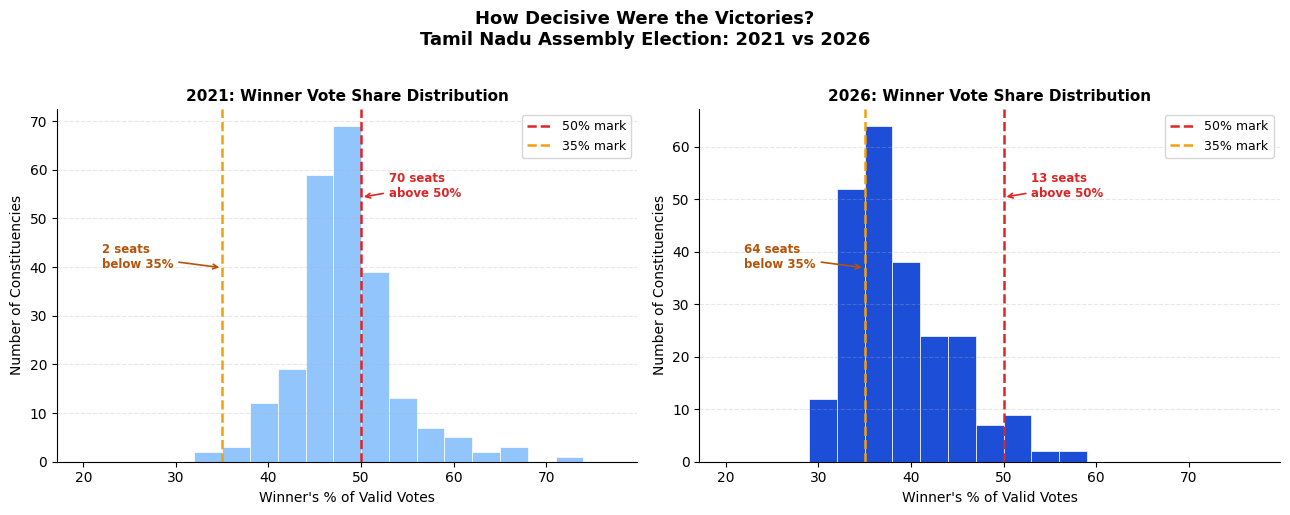

✅ Chart saved


In [16]:
# ═══════════════════════════════════════════════════
# Q6 CHART: Side-by-side distribution of vote share
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
bins = range(20, 80, 3)

for ax, col, color, year, above_50, below_35 in [
    (axes[0], 'winner_vote_share_2021', '#93C5FD', '2021', above_50_2021, below_35_2021),
    (axes[1], 'winner_vote_share_2026', '#1D4ED8', '2026', above_50_2026, below_35_2026),
]:
    ax.hist(combined[col].dropna(), bins=bins,
            color=color, edgecolor='white', linewidth=0.5)

    ax.axvline(50, color='#DC2626', linestyle='--', linewidth=1.8, label='50% mark')
    ax.axvline(35, color='#F59E0B', linestyle='--', linewidth=1.8, label='35% mark')

    y_max = ax.get_ylim()[1]

    # ── >50% annotation (right of red line) ──────────────
    ax.annotate(
        f'{above_50} seats\nabove 50%',
        xy=(50, y_max * 0.75),
        xytext=(53, y_max * 0.75),
        fontsize=8.5, color='#DC2626', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.2)
    )

    # ── <35% annotation (left of orange line) ────────────
    ax.annotate(
        f'{below_35} seats\nbelow 35%',
        xy=(35, y_max * 0.55),
        xytext=(22, y_max * 0.55),
        fontsize=8.5, color='#B45309', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#B45309', lw=1.2)
    )

    ax.set_title(f'{year}: Winner Vote Share Distribution',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel("Winner's % of Valid Votes", fontsize=10)
    ax.set_ylabel('Number of Constituencies', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(
    'How Decisive Were the Victories?\nTamil Nadu Assembly Election: 2021 vs 2026',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('q6_vote_share_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

In [17]:
# ── Q6 TABULAR SUMMARY ────────────────────────────────────────────

summary_q6 = pd.DataFrame({
    'Metric': [
        'Total constituencies',
        'Average winner margin (votes)',
        'Winners above 50% vote share',
        'Winners between 35–50% vote share',
        'Winners below 35% vote share',
        'Highest winner vote share',
        'Lowest winner vote share',
        'Median winner vote share',
    ],
    '2021': [
        234,
        f"{combined['margin_2021'].mean():,.0f}",
        f"{above_50_2021} ({above_50_2021/234*100:.1f}%)",
        f"{234 - above_50_2021 - below_35_2021} ({(234-above_50_2021-below_35_2021)/234*100:.1f}%)",
        f"{below_35_2021} ({below_35_2021/234*100:.1f}%)",
        f"{combined['winner_vote_share_2021'].max():.1f}%",
        f"{combined['winner_vote_share_2021'].min():.1f}%",
        f"{combined['winner_vote_share_2021'].median():.1f}%",
    ],
    '2026': [
        234,
        f"{combined['margin_2026'].mean():,.0f}",
        f"{above_50_2026} ({above_50_2026/234*100:.1f}%)",
        f"{234 - above_50_2026 - below_35_2026} ({(234-above_50_2026-below_35_2026)/234*100:.1f}%)",
        f"{below_35_2026} ({below_35_2026/234*100:.1f}%)",
        f"{combined['winner_vote_share_2026'].max():.1f}%",
        f"{combined['winner_vote_share_2026'].min():.1f}%",
        f"{combined['winner_vote_share_2026'].median():.1f}%",
    ]
})

print("\n══════════════════════════════════════════")
print("  Q6 SUMMARY TABLE — MARGINS OF VICTORY")
print("══════════════════════════════════════════")
display(summary_q6)

# Also show top 10 most decisive wins in 2026
print("\nTOP 10 MOST DECISIVE WINS — 2026 (by vote share)")
top_decisive = (
    combined[['constituency','region','reserved',
               'winner_2026','winning_party_2026',
               'winner_vote_share_2026','margin_2026']]
    .sort_values('winner_vote_share_2026', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_decisive)

# Top 10 closest races 2026
print("\nTOP 10 CLOSEST RACES — 2026 (by margin)")
closest = (
    combined[['constituency','region','reserved',
               'winner_2026','winning_party_2026',
               'winner_vote_share_2026','margin_2026']]
    .sort_values('margin_2026', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
display(closest)


══════════════════════════════════════════
  Q6 SUMMARY TABLE — MARGINS OF VICTORY
══════════════════════════════════════════


,Metric,2021,2026
0,Total constituencies,234,234
1,Average winner margin (votes),"22,871","16,784"
2,Winners above 50% vote share,70 (29.9%),13 (5.6%)
3,Winners between 35–50% vote share,162 (69.2%),157 (67.1%)
4,Winners below 35% vote share,2 (0.9%),64 (27.4%)
5,Highest winner vote share,72.1%,58.9%
6,Lowest winner vote share,33.5%,29.3%
7,Median winner vote share,48.2%,37.4%



TOP 10 MOST DECISIVE WINS — 2026 (by vote share)


,constituency,region,reserved,winner_2026,winning_party_2026,winner_vote_share_2026,margin_2026
0,Perambur,Chennai Metro,GEN,C. JOSEPH VIJAY,TVK,58.89,53715
1,Edappadi,Central,GEN,EDAPPADI PALANISWAMI. K,AIADMK,57.67,98110
2,Dr.Radhakrishnan Nagar,Chennai Metro,GEN,N. MARIE WILSON,TVK,53.97,49668
3,Thiruvottiyur,Chennai Metro,GEN,SENTHIL KUMAR. N,TVK,53.15,53564
4,Madavaram,Chennai Metro,GEN,M.L.VIJAYPRABHU,TVK,52.61,94985
5,Poonamallee,Chennai Metro,SC,PRAKASAM.R,TVK,52.22,72740
6,Avadi,Chennai Metro,GEN,R.RAMESH KUMAR,TVK,52.13,76311
7,Viralimalai,Delta,GEN,VIJAYABASKAR. C,AIADMK,51.87,62073
8,Tiruppattur,North,GEN,DR.THIRUPATHI. N,TVK,51.79,48263
9,Salem (West),Central,GEN,LAKSHMANAN.S,TVK,51.37,74867



TOP 10 CLOSEST RACES — 2026 (by margin)


,constituency,region,reserved,winner_2026,winning_party_2026,winner_vote_share_2026,margin_2026
0,Tiruppattur,South,GEN,SEENIVASA SETHUPATHY. R,TVK,38.65,1
1,Veppanahalli,North,GEN,SRINIVASAN.P.S,DMK,33.55,138
2,Kanniyakumari,South,GEN,THALAVAI SUNDARAM. N,AIADMK,31.38,214
3,Polur,North,GEN,ABISHEK. R,TVK,32.10,227
4,Tirukkoyilur,Central,GEN,PALANISAMY S,AIADMK,33.61,285
5,Paramathi-Velur,Central,GEN,SEKAR S,AIADMK,32.49,308
6,Kulithalai,Kongu,GEN,SURIYANUR. A. CHANDRAN,DMK,32.59,579
7,Kumbakonam,Delta,GEN,VINOTH,TVK,37.76,679
8,Palani,South,GEN,RAVIMANOHARAN. K,AIADMK,32.11,693
9,Tindivanam,Central,SC,VANNI ARASU,VCK,32.56,734


# Q2 — Flip Story

In [18]:
# ═══════════════════════════════════════════════════
# Q2 ANALYSIS: SEAT FLIP STORY
# ═══════════════════════════════════════════════════

# ── How many seats flipped ──
total        = len(combined)
flipped      = combined['seat_flipped'].sum()
held         = total - flipped

print("── HEADLINE NUMBERS (Q2) ──")
print(f"Total seats            : {total}")
print(f"Seats that flipped     : {flipped} ({flipped/total*100:.1f}%)")
print(f"Seats that held        : {held}   ({held/total*100:.1f}%)")

# ── Party-to-party flow (for Sankey) ──
flow = (
    combined[combined['seat_flipped']]
    .groupby(['winning_party_2021','winning_party_2026'])
    .size()
    .reset_index(name='seats')
    .sort_values('seats', ascending=False)
)

print("\nTOP SEAT FLOWS (2021 party → 2026 party):")
display(flow.head(20))

# ── Seats held by party ──
held_df = (
    combined[~combined['seat_flipped']]
    .groupby('winning_party_2026')
    .size()
    .reset_index(name='seats_held')
    .sort_values('seats_held', ascending=False)
)
print("\nSEATS HELD (same party won both years):")
display(held_df)

# ── Net gain/loss by party ──
seats_2021 = combined['winning_party_2021'].value_counts().rename('seats_2021')
seats_2026 = combined['winning_party_2026'].value_counts().rename('seats_2026')

net_change = pd.concat([seats_2021, seats_2026], axis=1).fillna(0).astype(int)
net_change['net_change'] = net_change['seats_2026'] - net_change['seats_2021']
net_change = net_change.sort_values('seats_2026', ascending=False)

print("\nSEAT COUNT CHANGE BY PARTY:")
display(net_change)

── HEADLINE NUMBERS (Q2) ──
Total seats            : 234
Seats that flipped     : 163 (69.7%)
Seats that held        : 71   (30.3%)

TOP SEAT FLOWS (2021 party → 2026 party):


,winning_party_2021,winning_party_2026,seats
13,DMK,TVK,65
3,AIADMK,TVK,26
8,DMK,AIADMK,22
0,AIADMK,DMK,15
17,INC,TVK,11
12,DMK,PMK,3
5,BJP,DMK,2
18,PMK,AIADMK,2
19,PMK,TVK,2
6,BJP,TVK,2



SEATS HELD (same party won both years):


,winning_party_2026,seats_held
3,DMK,40
0,AIADMK,22
4,INC,4
1,CPI,2
2,CPI(M),1
5,PMK,1
6,VCK,1



SEAT COUNT CHANGE BY PARTY:


,seats_2021,seats_2026,net_change
TVK,0,108,108
DMK,133,59,-74
AIADMK,66,47,-19
INC,18,5,-13
PMK,5,4,-1
VCK,4,2,-2
CPI(M),2,2,0
CPI,2,2,0
IUML,0,2,2
BJP,4,1,-3


In [19]:
# !pip install kaleido -y
!pip install kaleido==0.2.1 -q
print("✅ Kaleido 0.2.1 installed")

✅ Kaleido 0.2.1 installed


In [21]:
# ═══════════════════════════════════════════════════
# Q2 SANKEY v3: Major parties + "Others" bucket
# ═══════════════════════════════════════════════════
import plotly.graph_objects as go

PARTY_COLORS = {
    'DMK'    : '#0EA5E9',
    'AIADMK' : '#10B981',
    'TVK'    : '#8B5CF6',
    'INC'    : '#F59E0B',
    'BJP'    : '#F97316',
    'PMK'    : '#06B6D4',
    'VCK'    : '#EC4899',
    'CPI'    : '#84CC16',
    'CPI(M)' : '#14B8A6',
    'NTK'    : '#A78BFA',
    'IND'    : '#94A3B8',
    'Others' : '#CBD5E1',
}
DEFAULT_COLOR = '#CBD5E1'

THRESHOLD = 3  # parties below this get merged into "Others"

# ── Identify major vs minor parties ───────────────────────────────
major_2021 = set(net_change[net_change['seats_2021'] >= THRESHOLD].index)
major_2026 = set(net_change[net_change['seats_2026'] >= THRESHOLD].index)
all_major  = list(major_2021 | major_2026)

print("Major parties included:", all_major)
print("Will be grouped as 'Others': all remaining parties")

# ── Remap minor parties to 'Others' ───────────────────────────────
def remap_party(p):
    return p if p in all_major else 'Others'

combined['party_2021_grouped'] = combined['winning_party_2021'].apply(remap_party)
combined['party_2026_grouped'] = combined['winning_party_2026'].apply(remap_party)

# ── Build flow table with grouped parties ─────────────────────────
flow_grouped = (
    combined
    .groupby(['party_2021_grouped', 'party_2026_grouped'])
    .size()
    .reset_index(name='seats')
    .sort_values('seats', ascending=False)
)

# ── Build node list ────────────────────────────────────────────────
all_parties  = all_major + ['Others']
nodes_left   = [f"{p} (2021)" for p in all_parties]
nodes_right  = [f"{p} (2026)" for p in all_parties]
all_nodes    = nodes_left + nodes_right
node_indices = {name: i for i, name in enumerate(all_nodes)}

# ── Node colours ──────────────────────────────────────────────────
def hex_to_rgba(hex_color, alpha=1.0):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f'rgba({r},{g},{b},{alpha})'

node_colors = (
    [hex_to_rgba(PARTY_COLORS.get(p, DEFAULT_COLOR), 0.55) for p in all_parties] +
    [hex_to_rgba(PARTY_COLORS.get(p, DEFAULT_COLOR), 1.00) for p in all_parties]
)

# ── Build source / target / value lists ───────────────────────────
sources, targets, values, link_colors = [], [], [], []

for _, row in flow_grouped.iterrows():
    src_label  = f"{row['party_2021_grouped']} (2021)"
    tgt_label  = f"{row['party_2026_grouped']} (2026)"

    if src_label not in node_indices or tgt_label not in node_indices:
        continue

    sources.append(node_indices[src_label])
    targets.append(node_indices[tgt_label])
    values.append(int(row['seats']))
    link_colors.append(
        hex_to_rgba(PARTY_COLORS.get(row['party_2021_grouped'], DEFAULT_COLOR), 0.25)
    )

# ── Verify counts ─────────────────────────────────────────────────
print(f"\nTotal seats in flows : {sum(values)} (should be 234)")

# ── Build figure ───────────────────────────────────────────────────
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20,
        thickness=28,
        label=all_nodes,
        color=node_colors,
        line=dict(color='white', width=0.8)
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title=dict(
        text=(
            f"Seat Flow: 2021 → 2026 Tamil Nadu Assembly Election<br>"
            f"<sub>{flipped} of {total} seats changed hands ({flipped/total*100:.0f}%)"
            f"&nbsp;|&nbsp;Each colour represents one party</sub>"
        ),
        font=dict(size=15)
    ),
    font=dict(size=11),
    height=650,
    margin=dict(l=20, r=20, t=90, b=20)
)

# ── Save ───────────────────────────────────────────────────────────
fig.write_html('q2_sankey.html')
import time; time.sleep(2)

try:
    fig.write_image('q2_sankey.png', width=1100, height=650, scale=2)
    print("✅ Sankey saved: q2_sankey.html and q2_sankey.png")
except Exception as e:
    print(f"⚠️ PNG skipped — use HTML: {e}")

fig.show()

Major parties included: ['PMK', 'VCK', 'TVK', 'AIADMK', 'DMK', 'INC', 'BJP']
Will be grouped as 'Others': all remaining parties

Total seats in flows : 234 (should be 234)
✅ Sankey saved: q2_sankey.html and q2_sankey.png


In [23]:

from google.colab import drive
drive.mount('/content/drive')

import shutil, os

output_dir = '/content/drive/MyDrive/TN_elections_project/outputs/'
os.makedirs(output_dir, exist_ok=True)

files_to_save = [
    'tn_election_combined.csv',
    'q5_top20_turnout.png',
    'q5_regional_turnout.png',
    'q2_sankey.html',
    'q2_sankey.png',
    'q6_vote_share_distribution.png',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, output_dir + f)
        print(f"✅ Saved: {f}")
    else:
        print(f"⚠️  Not found: {f}")

Mounted at /content/drive
✅ Saved: tn_election_combined.csv
⚠️  Not found: q5_top20_turnout.png
⚠️  Not found: q5_regional_turnout.png
✅ Saved: q2_sankey.html
✅ Saved: q2_sankey.png
✅ Saved: q6_vote_share_distribution.png
